In [119]:
# Import libraries for data handling and plotting
import pandas as pd 
import matplotlib.pyplot as plt 

In [120]:
# Load pre- and post-course datasets from CSV
pre_course = pd.read_csv('pre_course.csv', index_col=0)
post_course = pd.read_csv('post_course.csv', index_col=0)


In [121]:
# Clean and rename pre-course Q4 responses → M1–M9; drop row 6; preview
del pre_course["Q4.1"]
del pre_course["Q4.11"]

# Preprocess the data
d = {}
for i in range(2, 11):
    key = f"Q4.{i}"
    value = f"M{i-1}"
    d[key] = value

pre_course = pre_course.drop(6)
pre_course.rename(columns = d, inplace = True)
pre_course.reset_index(inplace = True, drop = True)
pre_course.head()

,Student Number,Start Time,Submit Time,Status,Q1,Q2,Q2.1,Q2.2,Q2.3,Q3.1,...,M3,M4,M5,M6,M7,M8,M9,Q5,Q6,Q7
0,1,2022-08-09 19:46:53.200,2022-08-09 19:48:06.710,Submitted,Yes,No answer,in Chemistry teaching labs,No answer,No answer,Neutral,...,False but I am not sure,True but I am not sure,I have no idea,I have no idea,False but I am not sure,False but I am not sure,I have no idea,Difference in potential,Difference in voltagw,Nil
1,2,2022-08-09 10:40:39.280,2022-08-09 10:46:53.903,Submitted,Yes,"Pre-University (e.g. Junior College, Polytechn...",in Chemistry teaching labs,No answer,Others,Neutral,...,True but I am not sure,"False, I am confident",True but I am not sure,True but I am not sure,"False, I am confident","False, I am confident",False but I am not sure,Used to measure concentration by measuring the...,Used to measure concentration by applying curr...,I'm interested to learn more!
2,3,2022-08-10 02:37:50.900,2022-08-11 10:07:25.657,Submitted,Yes,"Pre-University (e.g. Junior College, Polytechn...",No answer,No answer,No answer,Neutral,...,False but I am not sure,False but I am not sure,False but I am not sure,False but I am not sure,False but I am not sure,False but I am not sure,False but I am not sure,Potential measured can be used to find concent...,Currents can be measured by applying a fixed p...,I have not touched electrochemistry for about ...
3,5,2022-08-09 11:57:08.667,2022-08-09 12:06:04.880,Submitted,Yes,No answer,in Chemistry teaching labs,in other University modules,No answer,Neutral,...,False but I am not sure,True but I am not sure,True but I am not sure,False but I am not sure,False but I am not sure,True but I am not sure,"True, I am confident",Potentiometry is an electroanalytic method whe...,Voltammetry is an electroanalytic method where...,NIL
4,6,2022-08-09 06:48:31.240,2022-08-09 07:09:04.273,Submitted,Yes,"Pre-University (e.g. Junior College, Polytechn...",No answer,in other University modules,No answer,Strongly Agree,...,False but I am not sure,"True, I am confident","False, I am confident","False, I am confident","False, I am confident","False, I am confident","False, I am confident",The chemical analysis technique is used to obt...,Electrochemical analysis technique where a ran...,Electrochemistry


In [122]:
# Clean and rename post-course Q4 responses → M1–M9; drop row 6; preview
del post_course["Q4.3"]

d = {}
d["Q4.1"] = "M1"
d["Q4.2"] = "M2"

for i in range(4, 11):
    key = f"Q4.{i}"
    value = f"M{i-1}"
    d[key] = value

post_course = post_course.drop(6)
post_course.rename(columns = d, inplace = True)
post_course.reset_index(inplace = True, drop = True)
post_course.head()

,Student Number,Start Time,Submit Time,Status,Q1,Q2,Q2.1,Q2.2,Q2.3,Q3.1,...,M9,Q5,Q6,Q7.1,Q7.2,Q7.3,Q7.4,Q7.5,Q8,Q9
0,1,2022-09-21 10:47:33.463,2022-09-21 10:49:18.587,Submitted,Yes,"Pre-University (e.g. Junior College, Polytechn...",No answer,No answer,No answer,Agree,...,True but I am not sure,the measure of the difference in potential,the measure of differencei n voltage,Agree,Agree,Agree,Agree,Agree,nil,nil
1,2,2022-09-21 14:45:01.423,2022-09-21 14:53:49.160,Submitted,Yes,"Pre-University (e.g. Junior College, Polytechn...",in Chemistry teaching labs,No answer,Others,Agree,...,False but I am not sure,Analytical tool used to measure the activity o...,An analytical tool to measure the activity of ...,Agree,Agree,Neutral,Strongly Disagree,Disagree,The project was difficult to carry and quite t...,Thank you prof. Sellou for your fun class and ...
2,3,2022-09-23 21:25:41.343,2022-09-23 21:34:24.110,Submitted,Yes,"Pre-University (e.g. Junior College, Polytechn...",No answer,No answer,No answer,Agree,...,False but I am not sure,the reaction occurs due to differences in elec...,analytical quantification method based on the ...,Agree,Agree,Neutral,Neutral,Agree,Those are really fun experiments!,NIL
3,5,2022-09-21 13:55:39.683,2022-09-21 14:24:52.207,Submitted,Yes,"Pre-University (e.g. Junior College, Polytechn...",in Chemistry teaching labs,No answer,No answer,Agree,...,"True, I am confident",The measure of voltage between two half cell t...,It is the measurement of current when a forced...,Neutral,Disagree,Disagree,Disagree,Strongly Disagree,"Firstly, the instructions were not very clear ...",Please take note that the assessment of the pr...
4,6,2022-09-20 21:04:34.863,2022-09-20 21:18:33.347,Submitted,Yes,"Pre-University (e.g. Junior College, Polytechn...",in Chemistry teaching labs,No answer,No answer,Agree,...,"False, I am confident","Potentiometry, electrolytic cell without batte...",Voltammetry (Electrolysis with potential appli...,Agree,Agree,Strongly Disagree,Agree,Neutral,The hands-on tutorial and project were a good ...,nil


In [123]:
# Select only M* (misconception) columns for analysis
# Filtering Q4 from pre-course and post-course
pre_course_p2 = pre_course.filter(regex='M')
post_course_p2= post_course.filter(regex='M')

In [124]:
# Preview first rows of pre-course M* responses
pre_course_p2.head()

,M1,M2,M3,M4,M5,M6,M7,M8,M9
0,False but I am not sure,I have no idea,False but I am not sure,True but I am not sure,I have no idea,I have no idea,False but I am not sure,False but I am not sure,I have no idea
1,"False, I am confident","True, I am confident",True but I am not sure,"False, I am confident",True but I am not sure,True but I am not sure,"False, I am confident","False, I am confident",False but I am not sure
2,False but I am not sure,False but I am not sure,False but I am not sure,False but I am not sure,False but I am not sure,False but I am not sure,False but I am not sure,False but I am not sure,False but I am not sure
3,False but I am not sure,True but I am not sure,False but I am not sure,True but I am not sure,True but I am not sure,False but I am not sure,False but I am not sure,True but I am not sure,"True, I am confident"
4,"False, I am confident","False, I am confident",False but I am not sure,"True, I am confident","False, I am confident","False, I am confident","False, I am confident","False, I am confident","False, I am confident"


In [125]:
# Preview first rows of post-course M* responses
post_course_p2.head()


,M1,M2,M3,M4,M5,M6,M7,M8,M9
0,True but I am not sure,I have no idea,"True, I am confident","True, I am confident",False but I am not sure,False but I am not sure,"False, I am confident",False but I am not sure,True but I am not sure
1,"False, I am confident","True, I am confident","False, I am confident","False, I am confident",True but I am not sure,"False, I am confident","False, I am confident","False, I am confident",False but I am not sure
2,False but I am not sure,False but I am not sure,False but I am not sure,False but I am not sure,False but I am not sure,"False, I am confident","False, I am confident","False, I am confident",False but I am not sure
3,"False, I am confident",False but I am not sure,"False, I am confident",I have no idea,"True, I am confident","False, I am confident","False, I am confident",False but I am not sure,"True, I am confident"
4,"False, I am confident","False, I am confident","False, I am confident","False, I am confident","True, I am confident","False, I am confident","False, I am confident","False, I am confident","False, I am confident"


In [126]:
# Compute percentage table for 'True' categories and export to CSV
def percentage_table(data, prefix = "Before: "):
    data_length = len(data)
    percentage_data = pd.DataFrame()
    for column in data.columns:
        value_counts_data = pd.DataFrame(data[column].value_counts())
        value_counts_data = value_counts_data.apply(lambda x: x/data_length * 100)
        percentage_data = pd.concat([percentage_data, value_counts_data], axis = 1)

    percentage_data.fillna(0, inplace=True)
    percentage_data = percentage_data.T
    percentage_data = percentage_data[["True, I am confident", "True but I am not sure"]]

    d = {"True, I am confident": prefix + "True, I am confident", 
         "True but I am not sure": prefix + "True but I am not sure"}
    percentage_data.rename(columns = d, inplace=True)
    return percentage_data

pre_percentage_mean = percentage_table(pre_course_p2)
post_percentage_mean = percentage_table(post_course_p2, "After: ")

percentage_mean = pd.concat([pre_percentage_mean, post_percentage_mean], axis = 1)
percentage_mean

percentage_mean.to_csv("percentage_table.csv")

In [127]:
# Map responses to (correctness, confidence) tuples and expand to .1/.2 (pre)
# pre-course pre-processing

# Get all values from pre_course_p2, we don't need to repeat for post_course 
values = list(set(pre_course_p2['M1'].values))

# These values will be used to split the data into two parts
map_d = {'True, I am confident': (0,1),
 'False but I am not sure': (1,0),
 'True but I am not sure': (0,0),
 'I have no idea': (0,0),
 'False, I am confident': (1,1)}

pre_course_p2_tup = pre_course_p2.applymap(lambda x: map_d[x])
new_pre_course_p2 = pd.DataFrame()

# Splitting, 1st part: False == Correct, 2nd part: Confidence 
for column in pre_course_p2_tup.columns:
    new_pre_course_p2[column + ".1"] = pre_course_p2_tup[column].apply(lambda x: x[0])
    new_pre_course_p2[column + ".2"] = pre_course_p2_tup[column].apply(lambda x: x[1])

new_pre_course_p2.head()

C:\Users\ky\AppData\Local\Temp\ipykernel_10336\1516929688.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pre_course_p2_tup = pre_course_p2.applymap(lambda x: map_d[x])


,M1.1,M1.2,M2.1,M2.2,M3.1,M3.2,M4.1,M4.2,M5.1,M5.2,M6.1,M6.2,M7.1,M7.2,M8.1,M8.2,M9.1,M9.2
0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0
1,1,1,0,1,0,0,1,1,0,0,0,0,1,1,1,1,1,0
2,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0
3,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,1
4,1,1,1,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1


In [128]:
# Helper to select columns ending with .1 (correct) or .2 (confidence)
# Let's make the code a lil simpler

def splitting(data, like = ".1"):
    like_list = ['.1', '.2']
    if like not in like_list:
        print("Invalid input, please try again")
        return
    
    like_list.remove(like)
    unlike = like_list[0]

    # Find the columns that end with like first
    filter_data = data.filter(like = like)

    # Filter since there might be outliers like Q4.1.2 which we do not want
    # final_filter = filter_data.loc[:, ~filter_data.columns.str.endswith(unlike)]
    return filter_data

In [129]:
# Split pre-course data into correctness (.1) and confidence (.2) subsets
#pre course splitting
#Split .1
pre_course_p2_correct = splitting(new_pre_course_p2)

# Repeat with .2
pre_course_p2_confident = splitting(new_pre_course_p2, like = '.2')


In [130]:
# Build maps to strip .1/.2 suffixes from column names (pre)
# Let's rename the data such that there's no .1 
question_names_correct = {}
question_names_confident = {}

correct_columns = pre_course_p2_correct.columns
confident_columns = pre_course_p2_confident.columns

for i in range(len(correct_columns)):
    correct_key = correct_columns[i]
    confident_key = confident_columns[i]
    correct_value = correct_key[:-2]
    confident_value = confident_key[:-2]

    question_names_correct[correct_key] = correct_value
    question_names_confident[confident_key] = confident_value

In [131]:
# Inspect pre-course '.1' columns to verify mapping worked
for key in question_names_correct.keys():
    print(key)

M1.1
M2.1
M3.1
M4.1
M5.1
M6.1
M7.1
M8.1
M9.1


In [132]:
# Rename pre-course columns to add '_pre' suffix (correctness/confidence)
# now that we have the columns, we can rename them for pre-course
pre_correct_columns = {}
pre_confident_columns = {}

for key in question_names_correct.keys():
    value = question_names_correct[key] + "_pre"
    pre_correct_columns[key] = value

for key in question_names_confident.keys():
    value = question_names_confident[key] + "_pre"
    pre_confident_columns[key] = value

pre_course_p2_correct.rename(columns = pre_correct_columns, inplace = True)
pre_course_p2_confident.rename(columns = pre_confident_columns, inplace = True)

C:\Users\ky\AppData\Local\Temp\ipykernel_10336\2522215481.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pre_course_p2_correct.rename(columns = pre_correct_columns, inplace = True)
C:\Users\ky\AppData\Local\Temp\ipykernel_10336\2522215481.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pre_course_p2_confident.rename(columns = pre_confident_columns, inplace = True)


In [133]:
# Map responses to (correctness, confidence) tuples and expand to .1/.2 (post)
# post-course pre-processing
post_course_p2 = post_course_p2.dropna()
post_course_p2_tup = post_course_p2.applymap(lambda x: map_d[x])
new_post_course_p2 = pd.DataFrame()
for column in post_course_p2_tup.columns:
    new_post_course_p2[column + ".1"] = post_course_p2_tup[column].apply(lambda x: x[0])
    new_post_course_p2[column + ".2"] = post_course_p2_tup[column].apply(lambda x: x[1])

C:\Users\ky\AppData\Local\Temp\ipykernel_10336\3124187563.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  post_course_p2_tup = post_course_p2.applymap(lambda x: map_d[x])


In [134]:
# Split post-course data into correctness (.1) and confidence (.2) subsets
#pre course splitting
#Split .1
post_course_p2_correct = splitting(new_post_course_p2)

# Repeat with .2
post_course_p2_confident = splitting(new_post_course_p2, like = '.2')

In [135]:
# Rename post-course columns to add '_post' suffix (correctness/confidence)
# Renaming for post-course
post_correct_columns = {}
post_confident_columns = {}

for key in question_names_correct.keys():
    value = question_names_correct[key] + "_post"
    post_correct_columns[key] = value

for key in question_names_confident.keys():
    value = question_names_confident[key] + "_post"
    post_confident_columns[key] = value

post_course_p2_correct.rename(columns = post_correct_columns, inplace = True)
post_course_p2_confident.rename(columns = post_confident_columns, inplace = True)

C:\Users\ky\AppData\Local\Temp\ipykernel_10336\1396186447.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_course_p2_correct.rename(columns = post_correct_columns, inplace = True)
C:\Users\ky\AppData\Local\Temp\ipykernel_10336\1396186447.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_course_p2_confident.rename(columns = post_confident_columns, inplace = True)


In [146]:
# Pearson chi-squared tests comparing pre vs post distributions (per question)
import numpy as np
from scipy.stats import chi2_contingency

# Helper to compute 2x2 contingency for a single binary column pair
# Rows: [Pre, Post]; Cols: [0 (No), 1 (Yes)]
def contingency_2x2(pre_series, post_series):
    pre_yes = int(pre_series.sum())
    pre_no = int(len(pre_series) - pre_yes)
    post_yes = int(post_series.sum())
    post_no = int(len(post_series) - post_yes)
    return np.array([[pre_no, pre_yes], [post_no, post_yes]])

# Build chi-squared results for correctness
chi2_correct_rows = []
num_q = len(pre_course_p2_correct.columns)
for i in range(num_q):
    q = pre_course_p2_correct.columns[i][:-4]  # strip _pre
    pre_col = pre_course_p2_correct.iloc[:, i]
    post_col = post_course_p2_correct.iloc[:, i]
    table = contingency_2x2(pre_col, post_col)
    chi2, p, dof, expected = chi2_contingency(table)
    chi2_correct_rows.append({
        'Question': q,
        'Chi2': round(chi2, 4),
        'p_value': round(p, 4),
        'dof': int(dof),
        'Observed': table.tolist()
    })

chi2_correct_df = pd.DataFrame(chi2_correct_rows)
print("Chi-squared (Correctness):")
print(chi2_correct_df)

# Build chi-squared results for confidence
chi2_conf_rows = []
num_qc = len(pre_course_p2_confident.columns)
for i in range(num_qc):
    q = pre_course_p2_confident.columns[i][:-4]  # strip _pre
    pre_col = pre_course_p2_confident.iloc[:, i]
    post_col = post_course_p2_confident.iloc[:, i]
    table = contingency_2x2(pre_col, post_col)
    chi2, p, dof, expected = chi2_contingency(table)
    chi2_conf_rows.append({
        'Question': q,
        'Chi2': round(chi2, 4),
        'p_value': round(p, 4),
        'dof': int(dof),
        'Observed': table.tolist()
    })

chi2_conf_df = pd.DataFrame(chi2_conf_rows)
print("\nChi-squared (Confidence):")
print(chi2_conf_df)


Chi-squared (Correctness):
  Question    Chi2  p_value  dof              Observed
0       M1  0.0426   0.8365    1  [[18, 37], [16, 39]]
1       M2  0.8282   0.3628    1  [[15, 40], [10, 45]]
2       M3  0.0000   1.0000    1  [[21, 34], [20, 35]]
3       M4  0.1629   0.6865    1  [[20, 35], [17, 38]]
4       M5  0.9094   0.3403    1  [[30, 25], [24, 31]]
5       M6  2.3476   0.1255    1  [[18, 37], [10, 45]]
6       M7  1.8285   0.1763    1   [[11, 44], [5, 50]]
7       M8  4.9404   0.0262    1   [[12, 43], [3, 52]]
8       M9  1.0323   0.3096    1  [[40, 15], [34, 21]]

Chi-squared (Confidence):
  Question     Chi2  p_value  dof              Observed
0       M1   6.6393   0.0100    1  [[27, 28], [13, 42]]
1       M2   9.4212   0.0021    1  [[39, 16], [22, 33]]
2       M3   5.8645   0.0154    1  [[43, 12], [30, 25]]
3       M4   0.3327   0.5641    1  [[26, 29], [22, 33]]
4       M5   1.3745   0.2410    1  [[37, 18], [30, 25]]
5       M6  19.5531   0.0000    1  [[43, 12], [19, 36]]
6   

In [137]:
# Interleave pre/post columns and aggregate counts into single-row correct_data
# Function to concat correct together, and confident together

def concat_data(pre, post):
    combined = pd.DataFrame()
    for i in range(len(pre.columns)):
        pre_column = pre[pre.columns[i]]
        post_column = post[post.columns[i]]
        combined = pd.concat([combined, pre_column, post_column], axis = 1)
    return combined


def data_preprocessing(data):
    data = data.drop(6)
    data.reset_index(inplace = True, drop = True)
    data = data.astype(int)
    data = pd.DataFrame(data.sum()).T
    return data

correct_data = concat_data(pre_course_p2_correct, post_course_p2_correct)
correct_data = data_preprocessing(correct_data)


In [138]:
# Import plotting libraries for charts
import matplotlib.pyplot as plt
import seaborn as sns

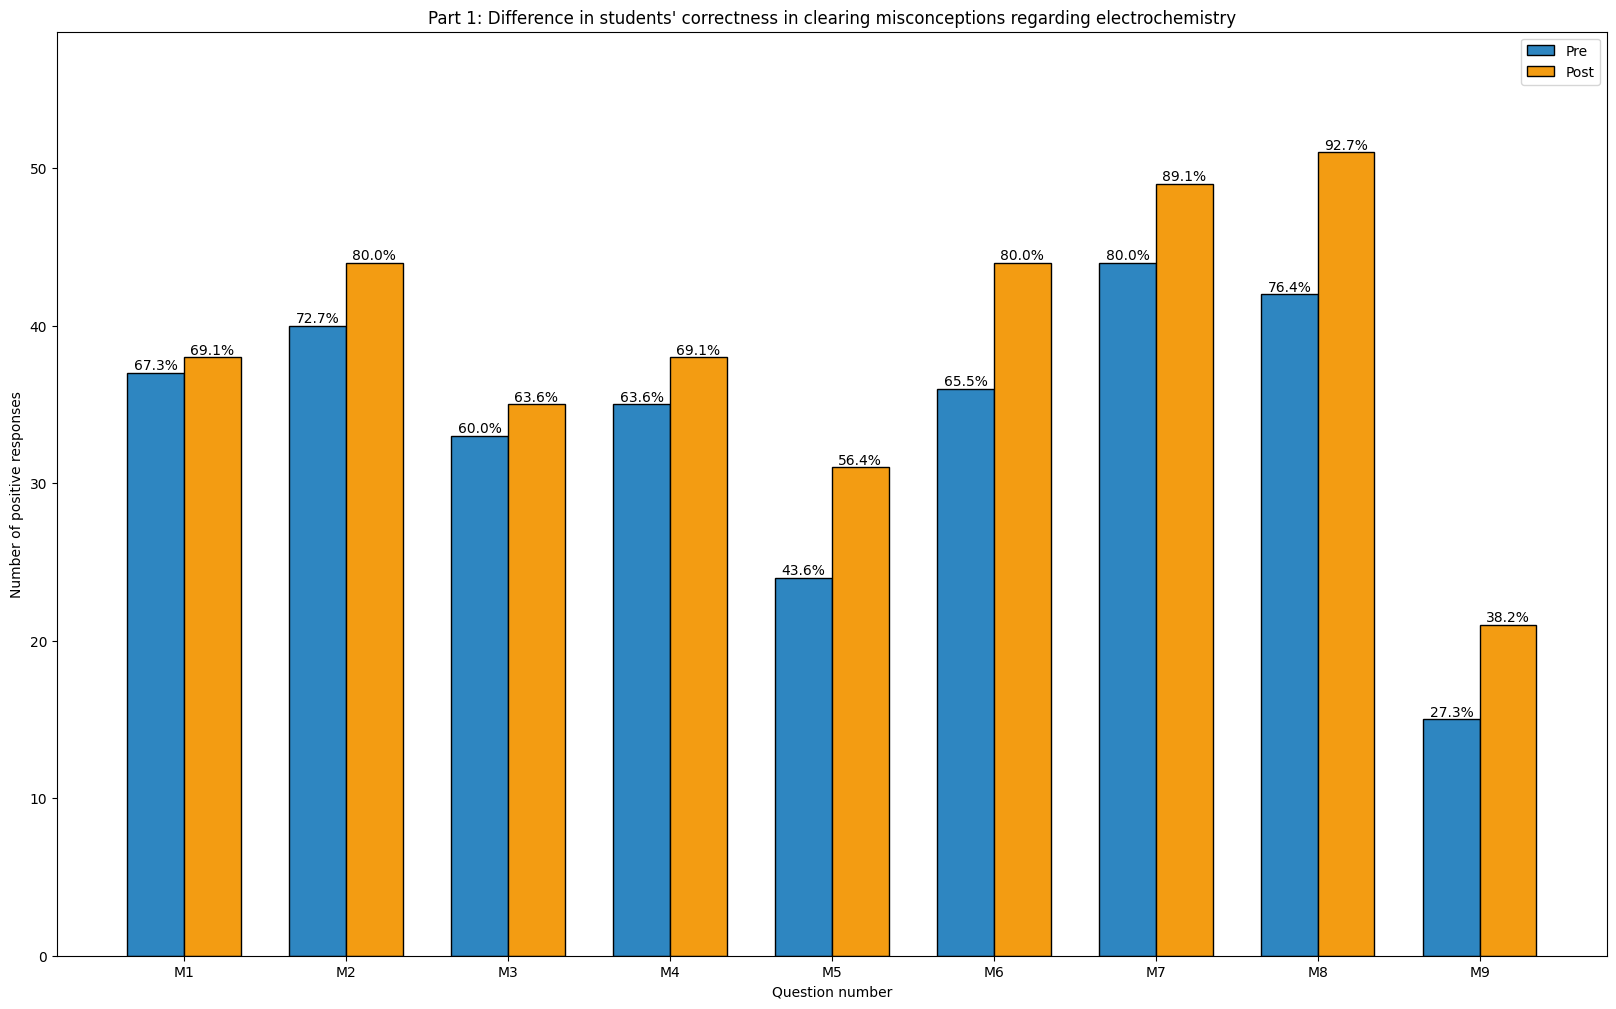

In [ ]:
# Plot correctness counts with percentage labels and save image
# Correctness Graph (counts on y-axis, percentage labels on bars)
fig, ax = plt.subplots(figsize=(20, 12))

n_questions = len(correct_data.columns) // 2
x = np.arange(n_questions)
width = 0.35

# Denominators (number of respondents)
total_pre = pre_course_p2_correct.shape[0]
total_post = post_course_p2_correct.shape[0]

max_count = 0
for i in range(n_questions):
    pre_count = int(correct_data.iloc[0, i*2])       # summed count
    post_count = int(correct_data.iloc[0, i*2+1])    # summed count
    max_count = max(max_count, pre_count, post_count)

    # Plot counts
    ax.bar(x[i] - width/2, pre_count, width, label='Pre' if i == 0 else "",
           color='#2E86C1', edgecolor='black', linewidth=1)
    ax.bar(x[i] + width/2, post_count, width, label='Post' if i == 0 else "",
           color='#F39C12', edgecolor='black', linewidth=1)

    # Percentage labels
    pre_pct = (pre_count / total_pre * 100) if total_pre else 0
    post_pct = (post_count / total_post * 100) if total_post else 0

    # Added percentage labels
    ax.text(x[i] - width/2, pre_count, f'{pre_pct:.1f}%', ha='center', va='bottom', fontsize=10)
    ax.text(x[i] + width/2, post_count, f'{post_pct:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, max_count * 1.15)
ax.set_ylabel('Number of positive responses')
ax.set_xlabel('Question number')
ax.set_title("Part 1: Difference in students' correctness in clearing misconceptions regarding electrochemistry")
ax.set_xticks(x)
ax.set_xticklabels([f'M{i+1}' for i in range(n_questions)])
ax.legend()

plt.savefig("graphs/Correctness Graph.png", bbox_inches='tight')
plt.show()

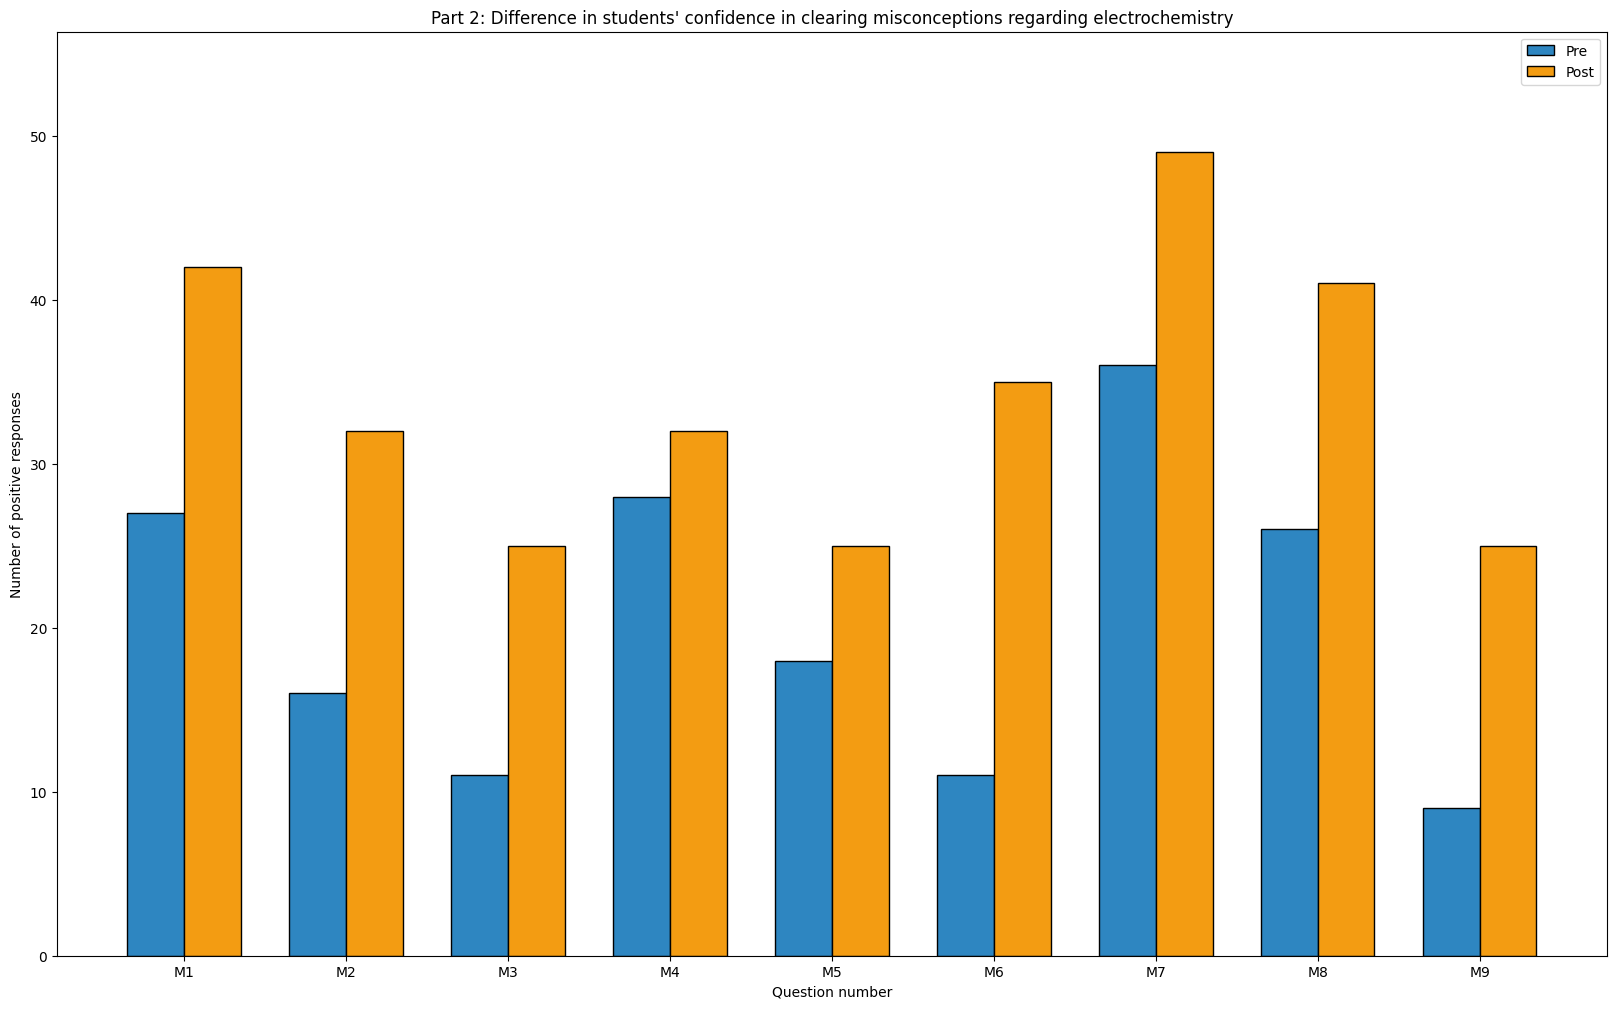

In [ ]:
# Plot confidence counts with percentage labels and save image
# Confidence Graph (counts on y-axis, percentage labels on bars)
fig, ax = plt.subplots(figsize=(20, 12))

n_questions = len(confident_data.columns) // 2
x = np.arange(n_questions)
width = 0.35

total_pre = pre_course_p2_confident.shape[0]
total_post = post_course_p2_confident.shape[0]

max_count = 0
for i in range(n_questions):
    pre_count = int(confident_data.iloc[0, i*2])
    post_count = int(confident_data.iloc[0, i*2+1])
    max_count = max(max_count, pre_count, post_count)

    ax.bar(x[i] - width/2, pre_count, width, label='Pre' if i == 0 else "",
           color='#2E86C1', edgecolor='black', linewidth=1)
    ax.bar(x[i] + width/2, post_count, width, label='Post' if i == 0 else "",
           color='#F39C12', edgecolor='black', linewidth=1)

    pre_pct = (pre_count / total_pre * 100) if total_pre else 0
    post_pct = (post_count / total_post * 100) if total_post else 0

    # Added percentage labels
    ax.text(x[i] - width/2, pre_count, f'{pre_pct:.1f}%', ha='center', va='bottom', fontsize=10)
    ax.text(x[i] + width/2, post_count, f'{post_pct:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, max_count * 1.15)
ax.set_ylabel('Number of positive responses')
ax.set_xlabel('Question number')
ax.set_title("Part 2: Difference in students' confidence in clearing misconceptions regarding electrochemistry")
ax.set_xticks(x)
ax.set_xticklabels([f'M{i+1}' for i in range(n_questions)])
ax.legend()

plt.savefig("graphs/Confidence Graph.png", bbox_inches='tight')
plt.show()

In [142]:
# Aggregate confidence counts into single-row confident_data
confident_data = concat_data(pre_course_p2_confident, post_course_p2_confident)
confident_data = data_preprocessing(confident_data)

In [144]:
# Build per-question correctness stats table (mean ± std, change)
# Create Table 2 for Correctness: Questions, Pre Mean ± Std, Post Mean ± Std, Change
import numpy as np

questions = [f"M{i+1}" for i in range(len(correct_data.columns) // 2)]

# Correctness - use individual data for std
correct_pre = pre_course_p2_correct
correct_post = post_course_p2_correct

correct_pre_means = correct_pre.mean().round(2)
correct_pre_stds = correct_pre.std().round(2)
correct_post_means = correct_post.mean().round(2)
correct_post_stds = correct_post.std().round(2)

# Convert to NumPy for aligned subtraction
correct_changes = np.subtract(correct_post_means.values, correct_pre_means.values).round(2)


correct_stats = pd.DataFrame({
       'Question': questions,
       'Pre-Course Mean ± Std': [f"{mean} ± {std}" for mean, std in zip(correct_pre_means, correct_pre_stds)],
       'Post-Course Mean ± Std': [f"{mean} ± {std}" for mean, std in zip(correct_post_means, correct_post_stds)],
       'Change': correct_changes.round(2)
   })

print("Correctness Table:")
print(correct_stats)


Correctness Table:
  Question Pre-Course Mean ± Std Post-Course Mean ± Std  Change
0       M1           0.67 ± 0.47            0.71 ± 0.46    0.04
1       M2           0.73 ± 0.45            0.82 ± 0.39    0.09
2       M3           0.62 ± 0.49            0.64 ± 0.49    0.02
3       M4           0.64 ± 0.49            0.69 ± 0.47    0.05
4       M5            0.45 ± 0.5             0.56 ± 0.5    0.11
5       M6           0.67 ± 0.47            0.82 ± 0.39    0.15
6       M7             0.8 ± 0.4            0.91 ± 0.29    0.11
7       M8           0.78 ± 0.42            0.95 ± 0.23    0.17
8       M9           0.27 ± 0.45            0.38 ± 0.49    0.11


In [145]:
# Build per-question confidence stats table (mean ± std, change)
# Create Table 2 for Confidence: Questions, Pre Mean ± Std, Post Mean ± Std, Change

# Confidence
confident_pre = pre_course_p2_confident  # Pre columns
confident_post = post_course_p2_confident  # Post columns

confident_pre_means = confident_pre.mean().round(2)
confident_pre_stds = confident_pre.std().round(2)
confident_post_means = confident_post.mean().round(2)
confident_post_stds = confident_post.std().round(2)

confident_changes = np.subtract(confident_post_means.values, confident_pre_means.values).round(2)


confident_stats = pd.DataFrame({
    'Question': questions,
    'Pre-Course Mean ± Std': [f"{mean} ± {std}" for mean, std in zip(confident_pre_means, confident_pre_stds)],
    'Post-Course Mean ± Std': [f"{mean} ± {std}" for mean, std in zip(confident_post_means, confident_post_stds)],
    'Change': confident_changes.round(2)
}, index=range(len(questions)))

print("Confidence Table:")
print(confident_stats)


Confidence Table:
  Question Pre-Course Mean ± Std Post-Course Mean ± Std  Change
0       M1            0.51 ± 0.5            0.76 ± 0.43    0.25
1       M2           0.29 ± 0.46             0.6 ± 0.49    0.31
2       M3           0.22 ± 0.42             0.45 ± 0.5    0.23
3       M4            0.53 ± 0.5             0.6 ± 0.49    0.07
4       M5           0.33 ± 0.47             0.45 ± 0.5    0.12
5       M6           0.22 ± 0.42            0.65 ± 0.48    0.43
6       M7           0.67 ± 0.47            0.91 ± 0.29    0.24
7       M8            0.49 ± 0.5            0.76 ± 0.43    0.27
8       M9           0.18 ± 0.39             0.45 ± 0.5    0.27
